In [14]:
import pandas as pd
# Infer datatype for column 14
df = pd.read_csv("data/clean/merged_df.csv", low_memory=False)
df.columns

Index(['hotel', 'lead_time', 'arrival_year', 'arrival_month',
       'stays_in_weekend_nights', 'stays_in_week_nights',
       'market_segment_type', 'country', 'avg_price_per_room', 'email',
       'is_canceled', 'arrival_day', 'arrival_date', 'Booking_ID'],
      dtype='object')

1. Calculate Cancelation rates for each month

In [17]:
cancel_rate_by_month = (
    df.groupby('arrival_month')['is_canceled']
    .mean()
    .mul(100)
    .reset_index(name='cancel_rate (%)')
    .sort_values('arrival_month')
)

print(cancel_rate_by_month)

    arrival_month  cancel_rate (%)
0               1        17.811159
1               2        31.581769
2               3        30.311891
3               4        37.432631
4               5        35.450718
5               6        39.870512
6               7        39.657187
7               8        38.472385
8               9        37.396653
9              10        37.179098
10             11        30.662983
11             12        28.293031


2. Compute Average price and average number of nights for each month.

In [22]:
df['stayed_nights'] = df['stays_in_week_nights'] + df['stays_in_weekend_nights']

df.groupby("arrival_month")[["avg_price_per_room", 'stayed_nights']].mean()

,avg_price_per_room,stayed_nights
arrival_month,,
1,67.870616,2.738197
2,73.340136,2.877033
3,83.276551,3.210805
4,93.302379,3.117834
5,102.000425,3.133358
6,108.858464,3.157151
7,114.074734,3.758181
8,122.761549,3.645985
9,108.360909,3.288313


3. Count monthly booking by market segment.

   - TA: Travel Agents
   - TO: Tour Operators

In [29]:
df['market_segment_type'].unique()

monthly_bookings = (
    df.groupby(["arrival_month", "market_segment_type"])
      .size()                      # counts the number of rows (bookings)
      .reset_index(name="bookings")  # rename the count column
)

monthly_bookings

,arrival_month,market_segment_type,bookings
0,1,Complementary,66
1,1,Corporate,298
2,1,Direct,369
3,1,Groups,205
4,1,Offline,314
...,...,...,...
101,12,Groups,820
102,12,Offline,716
103,12,Offline TA/TO,1439
104,12,Online,2041


4. Identify the most popular month of the year for bookings based on revenue.

In [34]:
# If not already extracted
df["month"] = pd.to_datetime(df["arrival_date"]).dt.month

# Compute total revenue per month
monthly_revenue = df.groupby("month")["avg_price_per_room"].sum().reset_index()

# Identify the top month
most_popular_month = monthly_revenue.loc[monthly_revenue["avg_price_per_room"].idxmax()]
print(f"Most popular month: {most_popular_month['month']} with total revenue: {most_popular_month['avg_price_per_room']:.2f}")

Most popular month: 9.0 with total revenue: 1638308.59


<Axes: title={'center': 'Monthly Revenue by Bookings'}, xlabel='month'>

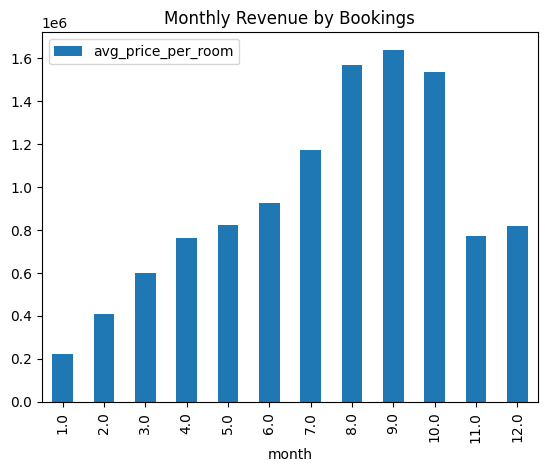

In [36]:
monthly_revenue.plot(x="month", y="avg_price_per_room", kind="bar", title="Monthly Revenue by Bookings")